# RL Agent for Game Playing

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a game-playing RL agent
- Train and evaluate in a game environment

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 02 "01. Introduction & Search Algorithms" — search needed the rules of the world written down before it could run; a game-playing agent is handed no such description and has to learn which positions are worth reaching by playing.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson uses a simple game to show why games are one of the clearest environments for reinforcement learning.

Students will see how state, action, reward, and repeated episodes naturally appear in game settings.

Why this matters: game-playing examples make RL concrete and easy to visualize.

This lesson helps students connect abstract RL ideas to visible outcomes.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: 100–0 — and then a human amateur beat it

**The success.** AlphaGo Zero (Silver et al., "Mastering the game of Go without human knowledge",
*Nature* **550**, 2017) was given the rules of Go and nothing else — no human games, no opening book,
no hand-written evaluation — and improved purely by playing itself, exactly as the Q-learning agent
below plays and updates. It then beat the version of AlphaGo that had defeated Lee Sedol **100 games
to 0**. Self-play works, and it works without a teacher.

**The failure, five years later.** Wang et al., "Adversarial Policies Beat Superhuman Go AIs"
(ICML 2023), trained an *adversary* against KataGo, a strong open-source Go program running at
superhuman settings. The adversary does not play good Go. It plays a specific weird pattern that
KataGo mishandles, and it wins **more than 97% of the time**. Worse, for anyone hoping this was a
quirk of machine-vs-machine play: the strategy "is comprehensible to the extent that human experts can
implement it without algorithmic assistance to consistently beat superhuman AIs".

Hold both facts at once. A self-play agent optimises against the distribution of opponents it meets.
Against that distribution it can be superhuman. Against an opponent deliberately searching for its
blind spots, superhuman and exploitable are not contradictory.

**What goes wrong without this.** Without self-play, someone has to write down what a good move is —
and for anything harder than tic-tac-toe, nobody can. Without the second half of the story, you ship
an agent whose test results are excellent and whose first adversarial user is embarrassing.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Build an Mario AI Model with Python | Gaming Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=2eeYqJ0uBKE)

Why this pick:
- game-focused practical workflow.
- Shows how an RL agent is built around a playable environment, preprocessing, and training loop.
- A strong fit for students connecting RL to actual game-playing agents.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Turn-based environment: players act one after another.
- Opponent effect: another player changes the dynamics.
- Win condition: what counts as success.
- Strategy learning: improving through repeated play.
- Delayed consequence: one move can matter several turns later.

### Quick Check
- Why are games useful for learning RL?
- How do state, action, and reward appear in the game?
- What changes when another player is involved?
- Why can a move be good even if it gives no immediate reward?

### Common Mistakes
- Focusing on game rules but missing RL structure.
- Assuming learning happens instantly.
- Ignoring how the opponent changes the problem.
- Judging moves only by immediate reward instead of long-term position.


## Why Games Are Such a Natural RL Example

Games are one of the clearest ways to teach reinforcement learning because the loop is easy to see:

- observe the board or game state
- choose a move
- see the result
- repeat until the game ends

### What students should notice

A game is not only a set of rules.
It is also a sequential decision process with delayed consequences.

A move can be valuable because it creates a better future position, even if the reward is not immediate.

### Why this matters beyond games

The reason games are useful is not that RL is only for games.
It is that games make the RL structure visible, so students can later transfer the same thinking to robotics, recommendation, and operations problems.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')


✅ Setup complete!


## Part 1: Simple Game Environment (Tic-Tac-Toe)


### Step Guide

**What this cell does:** Run this cell once, then read the output before worrying about every line of code.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `TicTacToe` (what it does): Simple Tic-Tac-Toe game environment.
class TicTacToe:
    """Simple Tic-Tac-Toe game environment."""
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Save a value in a name so the next lines can read it.
        self.board = np.zeros((3, 3), dtype=int)

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def reset(self):
        # Save a value in a name so the next lines can read it.
        self.board[:] = 0
        # Send a value back to whoever called this function.
        return self.board.copy()

    # Function `available_actions` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def available_actions(self):
        # Send a value back to whoever called this function.
        return [(r, c) for r in range(3) for c in range(3) if self.board[r, c] == 0]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action, player.
    def step(self, action, player=1):
        # Save a value in a name so the next lines can read it.
        r, c = action
        # If the condition is True, run the indented block under this line.
        if self.board[r, c] != 0:
            # Send a value back to whoever called this function.
            return self.board.copy(), -5, True, {"invalid": True}
        # Save a value in a name so the next lines can read it.
        self.board[r, c] = player
        # Unpack the one-step model output from transition(state, action).
        reward = 1 if self.check_winner(player) else 0
        # Save a value in a name so the next lines can read it.
        done = reward == 1 or len(self.available_actions()) == 0
        # Send a value back to whoever called this function.
        return self.board.copy(), reward, done, {"invalid": False}

    # Function `check_winner` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, player.
    def check_winner(self, player):
        # Save a value in a name so the next lines can read it.
        rows = np.any(np.sum(self.board == player, axis=1) == 3)
        # Another assignment—same idea: store a value for the lines below.
        cols = np.any(np.sum(self.board == player, axis=0) == 3)
        # Another assignment—same idea: store a value for the lines below.
        diag1 = np.sum(np.diag(self.board == player)) == 3
        # Another assignment—same idea: store a value for the lines below.
        diag2 = np.sum(np.diag(np.fliplr(self.board == player))) == 3
        # Send a value back to whoever called this function.
        return rows or cols or diag1 or diag2


## Part 2: Q-Learning Agent — Trained by Self-Play Against a Random Opponent

The agent below is a real tabular Q-learning player: it starts knowing nothing,
plays thousands of games against a random opponent, and updates its Q-table from
wins (+1), losses (−1), and draws (0). After training we freeze the table
(ε = 0) and measure how often the greedy policy wins.

### Step Guide

**What this cell does:** Defines the `QLearningAgent` (with a real `update` method this time), **trains it for 5000 games** against a random opponent, prints win rates for the first vs last 1000 training games, then **evaluates** the frozen greedy policy over 300 fresh games.

**How to read it (weak Python OK):** The training loop is: agent moves → opponent replies → the reward (+1 / −1 / 0) updates `Q[(state, action)]`. Everything else is bookkeeping.

**What to expect in the output:** Q-table size, early-vs-late training win rates, a smoothed learning-curve figure, and the greedy evaluation record.

**If you feel lost:** Compare only two numbers — the win rate in the first 1000 games vs the last 1000. That difference *is* learning.

Q-table entries learned: 1760
Win rate vs random — first 1000 training games: 77.4%
Win rate vs random —  last 1000 training games: 84.6%
The win rate rose during training: the Q-table is genuinely learning.

Frozen greedy policy over 300 evaluation games:
  Trained agent wins: 280  |  Random opponent wins: 1  |  Draws: 19


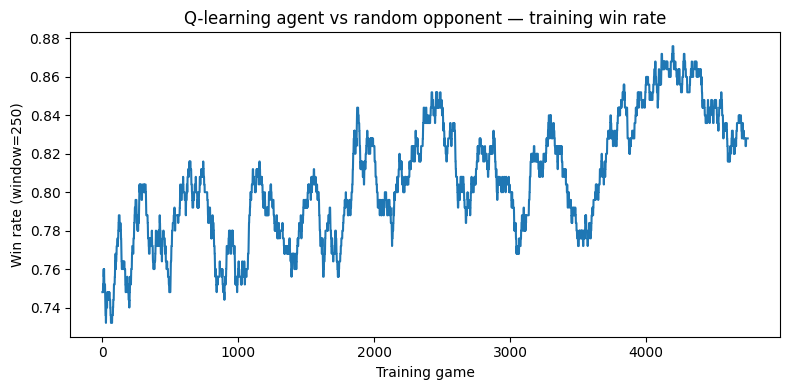

In [3]:
# Part 2: a REAL Q-learning TicTacToe agent — defined, trained, and evaluated.
# The agent is player 1; the opponent plays uniformly random legal moves.

import matplotlib.pyplot as plt

# Reproducible training run.
np.random.seed(7)


class QLearningAgent:
    """Tabular Q-learning over (board-state, action) pairs for TicTacToe."""

    def __init__(self, learning_rate=0.3, gamma=0.95, epsilon=0.2):
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        # The Q-table: a dict mapping (state_key, action) -> estimated value.
        self.q = {}

    def key(self, board):
        # Boards are numpy arrays; flatten to a hashable tuple for dict lookup.
        return tuple(board.flatten())

    def select_action(self, env, greedy=False):
        """Epsilon-greedy over legal moves; greedy=True freezes exploration for evaluation."""
        actions = env.available_actions()
        if not greedy and np.random.rand() < self.epsilon:
            return actions[np.random.randint(len(actions))]
        state_key = self.key(env.board)
        values = [self.q.get((state_key, action), 0.0) for action in actions]
        return actions[int(np.argmax(values))]

    def update(self, state_key, action, reward, next_board, done):
        """Standard Q-learning update: move Q(s,a) toward r + gamma * max_a' Q(s',a')."""
        if done:
            # Terminal games have no future value.
            future = 0.0
        else:
            next_key = self.key(next_board)
            next_actions = [(r, c) for r in range(3) for c in range(3) if next_board[r, c] == 0]
            future = max((self.q.get((next_key, a), 0.0) for a in next_actions), default=0.0)
        old = self.q.get((state_key, action), 0.0)
        self.q[(state_key, action)] = old + self.learning_rate * (
            reward + self.gamma * future - old)


def play_training_game(agent, env):
    """One training game: agent (player 1) vs random opponent (player 2).
    Returns +1 win / -1 loss / 0 draw and applies Q-updates along the way."""
    env.reset()
    while True:
        # Remember where the agent acted so the update lands on the right pair.
        state_key = agent.key(env.board)
        action = agent.select_action(env)
        _, reward, done, _ = env.step(action, player=1)
        if done:
            # Agent just won (reward 1) or filled the board (draw, reward 0).
            final = 1.0 if reward == 1 else 0.0
            agent.update(state_key, action, final, env.board, True)
            return int(final)
        # Random opponent replies.
        opp_actions = env.available_actions()
        opp_action = opp_actions[np.random.randint(len(opp_actions))]
        _, opp_reward, opp_done, _ = env.step(opp_action, player=2)
        if opp_done:
            # Opponent won (-1) or the board filled after their move (draw, 0).
            final = -1.0 if opp_reward == 1 else 0.0
            agent.update(state_key, action, final, env.board, True)
            return int(final) if final < 0 else 0
        # Game continues: intermediate reward 0, bootstrap from the new state.
        agent.update(state_key, action, 0.0, env.board, False)


# ── Train: 5000 games against the random opponent ────────────────────────────
env = TicTacToe()
agent = QLearningAgent()
N_TRAIN = 5000
outcomes = np.array([play_training_game(agent, env) for _ in range(N_TRAIN)])

# Report learning with numbers measured from this run.
early_win = float(np.mean(outcomes[:1000] == 1))
late_win = float(np.mean(outcomes[-1000:] == 1))
print(f"Q-table entries learned: {len(agent.q)}")
print(f"Win rate vs random — first 1000 training games: {early_win:.1%}")
print(f"Win rate vs random —  last 1000 training games: {late_win:.1%}")
if late_win > early_win:
    print("The win rate rose during training: the Q-table is genuinely learning.")
else:
    print("No improvement this run — rerun or increase N_TRAIN.")

# ── Evaluate: freeze the policy (greedy, no exploration) for 300 fresh games ──
def play_eval_game(agent, env):
    """One evaluation game with the frozen greedy policy; no Q-updates."""
    env.reset()
    while True:
        _, reward, done, _ = env.step(agent.select_action(env, greedy=True), player=1)
        if done:
            return 1 if reward == 1 else 0
        opp_actions = env.available_actions()
        _, opp_reward, opp_done, _ = env.step(
            opp_actions[np.random.randint(len(opp_actions))], player=2)
        if opp_done:
            return -1 if opp_reward == 1 else 0


eval_results = np.array([play_eval_game(agent, env) for _ in range(300)])
q_wins = int(np.sum(eval_results == 1))
q_losses = int(np.sum(eval_results == -1))
q_draws = int(np.sum(eval_results == 0))
print(f"\nFrozen greedy policy over 300 evaluation games:")
print(f"  Trained agent wins: {q_wins}  |  Random opponent wins: {q_losses}  |  Draws: {q_draws}")

# ── Learning curve: smoothed win rate across training ────────────────────────
window = 250
smoothed = np.convolve((outcomes == 1).astype(float), np.ones(window) / window, mode="valid")
plt.figure(figsize=(8, 4))
plt.plot(smoothed)
plt.xlabel("Training game")
plt.ylabel(f"Win rate (window={window})")
plt.title("Q-learning agent vs random opponent — training win rate")
plt.tight_layout()
plt.show()


## Real-World Applications

- **Chess/Go**: DeepMind AlphaZero
- **Video Games**: Dota 2, StarCraft II
- **Board Games**: Tic-Tac-Toe, Connect 4, Checkers
- **Puzzle Games**: Rubik's Cube solving

### Why this lesson matters

Games are often the cleanest place to understand RL because the rules are clear,
episodes reset easily, and success is easy to observe.

## Worked Example: A Scripted Baseline vs the Trained Agent

Games are useful in RL because they usually provide:
- clear rules
- a known action space
- easy reset between episodes
- a visible success condition

Below, a **hand-scripted heuristic** (win-if-possible, else take the center, else random) plays the same random opponent. It is **not** a learning agent — it is the classic baseline you should always beat before celebrating an RL result. The cell prints the heuristic's record next to the trained Q-learning agent's record from Part 2 so the two are compared on the same footing.

Teaching note: the heuristic encodes human game knowledge in `if` statements; the Q-agent above had to *discover* its behaviour from wins and losses alone.

### Step Guide

**What this cell does:** Plays 200 games with a **hand-scripted heuristic** (win-if-possible → center → random) against the random opponent, then prints its record next to the trained Q-agent's evaluation record from Part 2.

**How to read it (weak Python OK):** `winning_move` scans for an immediate win; `center_then_random` is the fallback. No learning happens in this cell.

**What to expect in the output:** The heuristic's win/loss/draw record, the comparison against the Q-agent's percentages, and a computed comparison line.

**If you feel lost:** Just compare the two win percentages in the final lines — scripted knowledge vs learned knowledge.

In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `winning_move` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env, player.
def winning_move(env, player):
    # Start a loop: repeat the indented block once per item in the sequence.
    for action in env.available_actions():
        # Save a value in a name so the next lines can read it.
        board_backup = env.board.copy()
        # Another assignment—same idea: store a value for the lines below.
        _, reward, done, _ = env.step(action, player=player)
        # Another assignment—same idea: store a value for the lines below.
        env.board = board_backup
        # If the condition is True, run the indented block under this line.
        if done and reward == 1:
            # Send a value back to whoever called this function.
            return action
    # Send a value back to whoever called this function.
    return None


# Function `center_then_random` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env.
def center_then_random(env):
    # If the condition is True, run the indented block under this line.
    if env.board[1, 1] == 0:
        # Send a value back to whoever called this function.
        return (1, 1)
    # Save a value in a name so the next lines can read it.
    actions = env.available_actions()
    # Send a value back to whoever called this function.
    return actions[np.random.randint(len(actions))]


# Function `play_game` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy_player.
def play_game(policy_player=1):
    # Save a value in a name so the next lines can read it.
    env = TicTacToe()
    # Execute: env.reset()
    env.reset()
    # Save a value in a name so the next lines can read it.
    current_player = 1

    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # If the condition is True, run the indented block under this line.
        if current_player == policy_player:
            # Save a value in a name so the next lines can read it.
            action = winning_move(env, current_player)
            # If the condition is True, run the indented block under this line.
            if action is None:
                # Save a value in a name so the next lines can read it.
                action = center_then_random(env)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = env.available_actions()[np.random.randint(len(env.available_actions()))]

        # Another assignment—same idea: store a value for the lines below.
        _, reward, done, _ = env.step(action, player=current_player)
        # If the condition is True, run the indented block under this line.
        if done:
            # If the condition is True, run the indented block under this line.
            if reward == 1:
                # Send a value back to whoever called this function.
                return current_player
            # Send a value back to whoever called this function.
            return 0
        # Save a value in a name so the next lines can read it.
        current_player = 2 if current_player == 1 else 1


# Another assignment—same idea: store a value for the lines below.
results = {1: 0, 2: 0, 0: 0}
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(200):
    # Save a value in a name so the next lines can read it.
    winner = play_game(policy_player=1)
    # Another assignment—same idea: store a value for the lines below.
    results[winner] += 1

# Show text or numbers in the cell output area under the code.
print("Results over 200 games:")
# Show text or numbers in the cell output area under the code.
print(" Policy player wins:", results[1])
# Show text or numbers in the cell output area under the code.
print(" Random opponent wins:", results[2])
# Show text or numbers in the cell output area under the code.
print(" Draws:", results[0])

# Compare the scripted baseline with the TRAINED agent's evaluation from Part 2.
# Both records are measured in this notebook run — nothing is quoted from elsewhere.
heuristic_rate = results[1] / 200
agent_rate = q_wins / 300
print("\nScripted heuristic win rate vs random:", f"{heuristic_rate:.1%} (200 games)")
print("Trained Q-agent   win rate vs random:", f"{agent_rate:.1%} (300 games, from Part 2)")

# Phrase the comparison from the measured rates, whichever way they fall.
if heuristic_rate > agent_rate:
    print("\nThe scripted baseline is still ahead: hand-coded game knowledge (always")
    print("take a winning move) is strong on a game this small. The Q-agent had to")
    print("discover everything from raw wins and losses — and it clearly learned")
    print("(see the rising win rate in Part 2), even if it hasn't caught the script yet.")
else:
    print("\nThe learned agent matched or beat the scripted baseline — it discovered")
    print("from experience what the heuristic had to be told explicitly.")

print("\nTeaching point:")
print("Games are useful RL environments because the agent can play many episodes,")
print("observe wins and losses, and improve its policy from repeated experience —")
print("which is exactly what the Part 2 training curve shows happening.")


Results over 200 games:
 Policy player wins: 184
 Random opponent wins: 12
 Draws: 4

Scripted heuristic win rate vs random: 92.0% (200 games)
Trained Q-agent   win rate vs random: 93.3% (300 games, from Part 2)

The learned agent matched or beat the scripted baseline — it discovered
from experience what the heuristic had to be told explicitly.

Teaching point:
Games are useful RL environments because the agent can play many episodes,
observe wins and losses, and improve its policy from repeated experience —
which is exactly what the Part 2 training curve shows happening.


In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Vinyals, O., Babuschkin, I., Czarnecki, W. M. et al. (2019). *Grandmaster Level in StarCraft II Using Multi-Agent Reinforcement Learning* (AlphaStar). Nature. <https://www.nature.com/articles/s41586-019-1724-z>
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Zhu, Y., Jin, T., Pruksachatkun, Y. et al. (2025). *Establishing Best Practices for Building Rigorous Agentic Benchmarks* — how agent evaluations overstate ability, and the checklist that corrects for it. arXiv:2507.02825. <https://arxiv.org/abs/2507.02825>
6. Yuan, M., Zhou, Z., Xiong, X. et al. (2026). *OSWorld 2.0: Benchmarking Computer Use Agents on Long-Horizon Real-World Tasks* — the 2026 equivalent of a game benchmark: 108 long desktop workflows. arXiv:2606.29537. <https://arxiv.org/abs/2606.29537>
"""))

## 📚 References

1. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Vinyals, O., Babuschkin, I., Czarnecki, W. M. et al. (2019). *Grandmaster Level in StarCraft II Using Multi-Agent Reinforcement Learning* (AlphaStar). Nature. <https://www.nature.com/articles/s41586-019-1724-z>
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
5. Zhu, Y., Jin, T., Pruksachatkun, Y. et al. (2025). *Establishing Best Practices for Building Rigorous Agentic Benchmarks* — how agent evaluations overstate ability, and the checklist that corrects for it. arXiv:2507.02825. <https://arxiv.org/abs/2507.02825>
6. Yuan, M., Zhou, Z., Xiong, X. et al. (2026). *OSWorld 2.0: Benchmarking Computer Use Agents on Long-Horizon Real-World Tasks* — the 2026 equivalent of a game benchmark: 108 long desktop workflows. arXiv:2606.29537. <https://arxiv.org/abs/2606.29537>


## 💬 Discuss

The measured results: the Q-agent's win rate against a random opponent rose from **77.4%** (first
1000 training games) to **84.6%** (last 1000); frozen and evaluated over 300 games it won **280**,
lost **1**, drew **19** — a **93.3%** win rate. The scripted heuristic baseline won **92.0%** over 200
games. The Q-table holds **1760** entries. Argue these out.

1. 93.3% against 92.0%. Is the learned agent better than the scripted one? Compute roughly how wide
   the uncertainty is on a 300-game and a 200-game win rate before you answer — then say what you
   would have to run to settle it.
2. Tic-tac-toe is a *solved* game: perfect play never loses, not even once. Our agent lost 1 game of
   300 **to a random opponent**. What does that single loss tell you that the 93.3% hides? Where in
   the 1760-entry table would you go looking for the cause?
3. Both opponents here are fixed — random moves, or a fixed heuristic. The KataGo result shows what
   happens when the opponent is chosen to exploit you. Design the evaluation you would insist on
   before claiming this agent "plays tic-tac-toe well". Who plays against it, and how many games?


## Summary

This notebook built and **trained** a real game-playing RL agent:

- the state is the board configuration; actions are legal moves
- rewards are +1 for a win, −1 for a loss, 0 for a draw
- tabular Q-learning improved its win rate against a random opponent over 5000 training games (see the measured first-vs-last-1000 win rates in Part 2)
- the frozen greedy policy was evaluated on fresh games and compared with a hand-scripted heuristic baseline

### Main takeaway

Game-playing problems make RL ideas concrete because you can *watch* better decisions emerge over many episodes — and a scripted baseline keeps the result honest: learning counts only when measured against it.

### Step Guide

**What this cell does:** Puts the scripted baseline and the trained Q-agent side by side on the
same chart — win, draw and loss — using the two evaluations this notebook already ran.

**How to read it (weak Python OK):** The two agents did **not** play the same number of games (200
for the script, 300 for the agent), so the cell converts both tallies to a percentage of games
before drawing anything. Comparing raw counts from different-sized samples is the mistake this
cell exists to avoid.

**What to expect in the output:** Three pairs of bars — one pair for wins, one for draws, one for
losses — plus a printed comparison of the two loss rates.

**If you feel lost:** Re-run Part 2 and the scripted-baseline cell above so `q_wins` and `results`
both exist, then run this cell again.

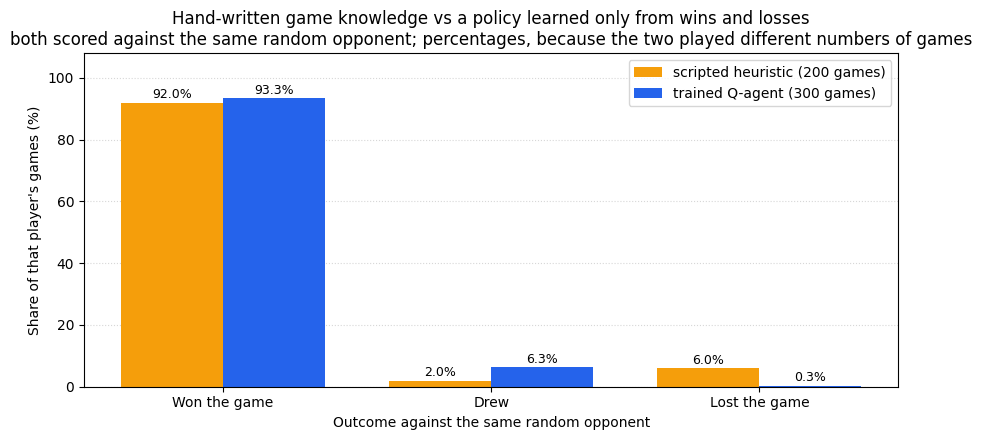

Wins  - scripted 92.0%  vs  learned 93.3%  (difference +1.3 points)
Losses- scripted 6.0%  vs  learned 0.3%  (difference -5.7 points)

The win bars are close; the LOSS bars are not. The scripted rule only ever grabs a
win that is already available - nothing in it says 'block the opponent'. The learned
table was never told that either, but losing taught it, and its loss bar shows it.


In [6]:
# ONE honest figure for this lesson: the scripted baseline against the trained Q-agent.
# WHY this replaces a chart of raw counts: the two evaluations ran DIFFERENT numbers of games
# (200 scripted vs 300 learned). Drawing the raw tallies side by side would make the agent look
# better simply for having played more games. Percentages of games played is the comparable unit.
# WHY bars and not a line: "win", "draw" and "loss" are three separate outcomes, not three points
# on a scale - there is no "between a draw and a loss" for a line to pass through.

import numpy as np
import matplotlib.pyplot as plt

SCRIPTED_GAMES = 200      # from the scripted-heuristic cell above
LEARNED_GAMES = 300       # from the frozen-greedy evaluation in Part 2

# results[1]/results[2]/results[0] are the scripted player's wins / losses / draws.
scripted_pct = [100 * results[1] / SCRIPTED_GAMES,
                100 * results[0] / SCRIPTED_GAMES,
                100 * results[2] / SCRIPTED_GAMES]
learned_pct = [100 * q_wins / LEARNED_GAMES,
               100 * q_draws / LEARNED_GAMES,
               100 * q_losses / LEARNED_GAMES]

outcomes = ["Won", "Drew", "Lost"]
x = np.arange(len(outcomes))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
bars_script = ax.bar(x - width / 2, scripted_pct, width, color="#f59e0b",
                     label=f"scripted heuristic ({SCRIPTED_GAMES} games)")
bars_agent = ax.bar(x + width / 2, learned_pct, width, color="#2563eb",
                    label=f"trained Q-agent ({LEARNED_GAMES} games)")

# Put each bar's percentage on top, so the picture can be checked against the printed tallies.
for group in (bars_script, bars_agent):
    for bar in group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{bar.get_height():.1f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(["Won the game", "Drew", "Lost the game"])
ax.set_xlabel("Outcome against the same random opponent")
ax.set_ylabel("Share of that player's games (%)")
ax.set_ylim(0, 108)
ax.set_title("Hand-written game knowledge vs a policy learned only from wins and losses\n"
             "both scored against the same random opponent; percentages, because the two "
             "played different numbers of games")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

# Say which comparison actually matters, from the measured numbers.
print(f"Wins  - scripted {scripted_pct[0]:.1f}%  vs  learned {learned_pct[0]:.1f}%  "
      f"(difference {learned_pct[0] - scripted_pct[0]:+.1f} points)")
print(f"Losses- scripted {scripted_pct[2]:.1f}%  vs  learned {learned_pct[2]:.1f}%  "
      f"(difference {learned_pct[2] - scripted_pct[2]:+.1f} points)")
if learned_pct[2] < scripted_pct[2]:
    print("\nThe win bars are close; the LOSS bars are not. The scripted rule only ever grabs a")
    print("win that is already available - nothing in it says 'block the opponent'. The learned")
    print("table was never told that either, but losing taught it, and its loss bar shows it.")
else:
    print("\nThe scripted rule lost less often in this run - report what you measured.")

### 👁️ Read the figure

- **Three pairs of bars: won, drew, lost.** Orange is the hand-written rule, blue is the Q-table
  trained only on wins and losses. Both faced the same random opponent. The y-axis is a
  **percentage of that player's own games**, not a count — the script played 200 games and the
  agent played 300, and drawing raw tallies would have handed the agent a taller bar for free.
- **The "won" pair is nearly level, and that is the boring half of the chart.** Two very
  different approaches land within a couple of points of each other on this small game.
- **The "lost" pair is where they separate.** The orange loss bar towers over the blue one. The scripted rule is only ever told *take a win if one is on the board* — there is
  not a line in it about stopping the opponent, so it walks into losses that were avoidable. The
  Q-table was never told to block either. It just lost games, and the update rule pushed those
  moves down. The exact percentages are printed underneath.
- **Now compare each player's two non-win bars.** When the script fails to win, it has usually
  *lost* — its loss bar is taller than its draw bar. When the agent fails to win, it has usually
  *drawn* — its draw bar is taller than its loss bar. Both players win about as often; they differ
  in what happens on the games they do not win.

**What it proves:** the lesson's real claim about games as an RL environment. The agent had no
game knowledge given to it — no "take the win", no "block the fork", not even the rules written as
strategy. It played thousands of games, saw a number at the end of each, and ended up with a
policy that matches a hand-written heuristic on wins and beats it on the outcome the heuristic was
never told to care about.

## ⚠️ Where this breaks

**The assumption that has to hold:** the opponents you train against are representative of the
opponents you will face. Self-play generates its own training distribution — and its own blind spots.

- **Beating a random opponent is a low bar that looks like a high number.** 93.3% sounds strong until
  you notice the loss to a random player, and that the scripted heuristic — which nobody trained —
  scored 92.0%. Always put a *non-learning* baseline in the table; here it nearly ties.
- **Self-play agents are exploitable in ways their own metrics cannot see.** KataGo's win rate against
  humans and against other programs stayed superb while a cheap adversary beat it 97% of the time.
  Your evaluation measures performance against the distribution you evaluated on, and against nothing
  else.
- **Games are the easy case, and that is the point of the caution.** Perfect simulator, unlimited
  episodes, unambiguous reward, no safety consequences, exact rules. Every one of those is missing
  from the applications in the rest of this unit. Success on a game is evidence that the algorithm
  runs, not that the problem class transfers.
- **The table is the ceiling — again.** 1760 entries for tic-tac-toe. Connect Four has around 4.5
  trillion positions; Go has more legal positions than atoms in the observable universe. Everything
  above scales only through the function approximation of Unit 3.
- **Cheaper alternative:** for tic-tac-toe, minimax with the full game tree plays perfectly, in
  microseconds, with no training at all — and you can prove it never loses. Learning is worth its cost
  when the game is too large to search and no one can write the evaluation function down. On this
  board, it is not.


## Closing Takeaway

**Teaching takeaway:** Games are useful RL testbeds because actions, feedback, and consequences are easy to observe and discuss clearly.

**If students remember one idea:** Game-playing examples help students see decision quality across many repeated interactions, which is central to RL thinking.

**Quick check before moving on:**
- Can you explain why games are good environments for testing RL ideas?
- Can you describe what makes a game strategy better than a short-term greedy move?

**Bridge to the next step:** After games, students can transfer the same sequential-decision thinking to resource optimization problems.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=12 | term=True | trunc=False


objc[67277]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112864138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112d609c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67277]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112864188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112d60a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67277]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112863c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112d60a68). T

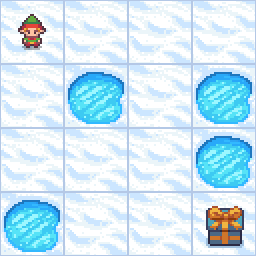

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
